<a href="https://colab.research.google.com/github/4GTTN/Colab/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Light

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

## Задание 1.
С помощью генетического алгоритма найдите точку, где функция от трёх переменных: f = x^2/y + z*(12-z) + 5*y/x равна 0 (символ ^2 -возведение в квадрат). Интервал изменения каждой переменной x, y, z и вывести на экран значение этой точки и значение функции в ней

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def getSurvPopul(popul, val, nsurv, reverse):
    newpopul = []
    sval = sorted(val, reverse=reverse)
    for i in range(nsurv):
        index = val.index(sval[i])
        newpopul.append(popul[index])
    return newpopul, sval

def getParents(curr_popul, nsurv):
    indexp1 = random.randint(0, nsurv - 1)
    indexp2 = random.randint(0, nsurv - 1)
    botp1 = curr_popul[indexp1]
    botp2 = curr_popul[indexp2]
    return botp1, botp2

def crossPointFrom2Parents(botp1, botp2, j):
    pindex = random.random()

    if pindex < 0.5:
        x = botp1[j]
    else:
        x = botp2[j]

    return x

n = 100
nsurv = 20
nnew = n - nsurv
l = 9
epohs = 500
mut = 0.25
popul = []

for i in range(n):
    popul.append([])
    for j in range(l):
        popul[i].append(random.random())

for it in range(epohs):
    val = []
    for i in range(n):
        bot = popul[i]
        x = bot[0] + 5*bot[1] + 10*bot[2]
        y = bot[3] + 5*bot[4] + 10*bot[5]
        z = bot[6] + 5*bot[7] + 10*bot[8]
        f = x*x/y + z*(12 - z) + 5*y/x
        val.append(abs(f))

    newpopul, sval = getSurvPopul(popul, val, nsurv, 0)
    print(it, " ", [round(s,8) for s in sval[0:5]])

    for i in range(nnew):
        botp1, botp2 = getParents(newpopul, nsurv)
        newbot = []
        for j in range(l):
            x = crossPointFrom2Parents(botp1, botp2, j)
            x += mut * (2*random.random() - 1.0)
            newbot.append(x)
        newpopul.append(newbot)
    popul = newpopul

bot = popul[0]

x = bot[0] + 5*bot[1] + 10*bot[2]
y = bot[3] + 5*bot[4] + 10*bot[5]
z = bot[6] + 5*bot[7] + 10*bot[8]
f = x*x/y + z*(12 - z) + 5*y/x

print("\nЛучшая найденная точка:")
print("x =", x)
print("y =", y)
print("z =", z)
print("\nЗначение функции:")
print("f =", f)

0   [2.54072386, 6.44184439, 6.87945547, 6.91981487, 9.40471439]
1   [0.06523141, 0.45610077, 0.60638794, 0.62646371, 1.89481956]
2   [0.06523141, 0.33713409, 0.40824538, 0.45610077, 0.60638794]
3   [0.06523141, 0.07923025, 0.12645219, 0.33713409, 0.40824538]
4   [0.06523141, 0.07923025, 0.12645219, 0.33713409, 0.40824538]
5   [0.06523141, 0.07923025, 0.12645219, 0.33713409, 0.40824538]
6   [0.06523141, 0.07923025, 0.12645219, 0.33713409, 0.40824538]
7   [0.04492025, 0.06523141, 0.07923025, 0.12645219, 0.33713409]
8   [0.02613308, 0.04492025, 0.06523141, 0.07923025, 0.12645219]
9   [0.02613308, 0.04492025, 0.06523141, 0.07923025, 0.12645219]
10   [0.02613308, 0.04492025, 0.06523141, 0.07923025, 0.12645219]
11   [0.02613308, 0.02864231, 0.04492025, 0.06523141, 0.07923025]
12   [0.02613308, 0.02864231, 0.04492025, 0.06523141, 0.07923025]
13   [0.02613308, 0.02864231, 0.04492025, 0.06523141, 0.07923025]
14   [0.02613308, 0.02864231, 0.04492025, 0.06523141, 0.07923025]
15   [0.02613308, 0.

## **Задание 2.**
Проведите анализ скорости сходимости до заданной вами точности (выберите точность, близкую к минимуму в прошлом примере) и заполните таблицу - какими были параметры и за сколько эпох алгоритм дошёл до нужной точности
  * Выберите три разные размера популяции
  * Выберите три разные коэффициента мутации
  * Выберите три разных количества выживших

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

def getSurvPopul(popul, val, nsurv, reverse):
    newpopul = []
    sval = sorted(val, reverse=reverse)
    for i in range(nsurv):
        index = val.index(sval[i])
        newpopul.append(popul[index])
    return newpopul, sval

def getParents(curr_popul, nsurv):
    indexp1 = random.randint(0, nsurv - 1)
    indexp2 = random.randint(0, nsurv - 1)
    botp1 = curr_popul[indexp1]
    botp2 = curr_popul[indexp2]

    return botp1, botp2

def crossPointFrom2Parents(botp1, botp2, j):
    pindex = random.random()
    if pindex < 0.5:
        x = botp1[j]
    else:
        x = botp2[j]
    return x

def run_genetic_algorithm(n, mut, nsurv):
    l = 9
    epohs = 500
    accuracy = 0.001
    nnew = n - nsurv
    popul = []

    for i in range(n):
        bot = []
        for j in range(l):
            bot.append(random.random())
        popul.append(bot)

    for it in range(epohs):
        val = []
        for i in range(n):
            bot = popul[i]
            x = bot[0] + 5*bot[1] + 10*bot[2]
            y = bot[3] + 5*bot[4] + 10*bot[5]
            z = bot[6] + 5*bot[7] + 10*bot[8]

            if x == 0:
                x = 0.0001
            if y == 0:
                y = 0.0001

            f = x*x/y + z*(12 - z) + 5*y/x

            val.append(abs(f))

        newpopul, sval = getSurvPopul(popul, val, nsurv, 0)

        if sval[0] < accuracy:
            return it

        for i in range(nnew):
            botp1, botp2 = getParents(newpopul, nsurv)
            newbot = []
            for j in range(l):
                x = crossPointFrom2Parents(botp1, botp2, j)
                x += mut * (2*random.random() - 1)
                newbot.append(x)
            newpopul.append(newbot)
        popul = newpopul
    return epohs

population_sizes = [50, 100, 200]
mutation_rates = [0.1, 0.25, 0.5]
survivor_counts = [10, 20, 40]

c = 0

for n in population_sizes:
    for mut in mutation_rates:
        for nsurv in survivor_counts:
            epochs_needed = run_genetic_algorithm(n, mut, nsurv)
            c += 1
            print(f"{c}. Размер популяции {n}, Мутация {mut}, Выжившие {nsurv}, Эпох до точности: {epochs_needed}")

1. Размер популяции 50, Мутация 0.1, Выжившие 10, Эпох до точности: 267
2. Размер популяции 50, Мутация 0.1, Выжившие 20, Эпох до точности: 500
3. Размер популяции 50, Мутация 0.1, Выжившие 40, Эпох до точности: 500
4. Размер популяции 50, Мутация 0.25, Выжившие 10, Эпох до точности: 131
5. Размер популяции 50, Мутация 0.25, Выжившие 20, Эпох до точности: 500
6. Размер популяции 50, Мутация 0.25, Выжившие 40, Эпох до точности: 500
7. Размер популяции 50, Мутация 0.5, Выжившие 10, Эпох до точности: 483
8. Размер популяции 50, Мутация 0.5, Выжившие 20, Эпох до точности: 500
9. Размер популяции 50, Мутация 0.5, Выжившие 40, Эпох до точности: 500
10. Размер популяции 100, Мутация 0.1, Выжившие 10, Эпох до точности: 204
11. Размер популяции 100, Мутация 0.1, Выжившие 20, Эпох до точности: 250
12. Размер популяции 100, Мутация 0.1, Выжившие 40, Эпох до точности: 331
13. Размер популяции 100, Мутация 0.25, Выжившие 10, Эпох до точности: 294
14. Размер популяции 100, Мутация 0.25, Выжившие 20,

## **Задание 3.**
Решите задачу расстановки грузов по поездам в усложнённом варианте, добейтесь полного распределение грузов по поездам:
Поезда - 1, 12, 72, 4, 55, 1
Грузы - 1, 1, 1, 1, 4, 3, 3, 3, 1, 27, 31, 7, 7, 11, 22, 7, 7, 8

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

def getSurvPopul(popul, val, nsurv, reverse):

    newpopul = []
    sval = sorted(val, reverse=reverse)
    for i in range(nsurv):
        index = val.index(sval[i])
        newpopul.append(popul[index])
    return newpopul, sval

def getParents(curr_popul, nsurv):

    indexp1 = random.randint(0, nsurv - 1)
    indexp2 = random.randint(0, nsurv - 1)
    botp1 = curr_popul[indexp1]
    botp2 = curr_popul[indexp2]

    return botp1, botp2

def crossPointFrom2Parents(botp1, botp2, j):

    pindex = random.random()
    if pindex < 0.5:
        x = botp1[j]
    else:
        x = botp2[j]
    return x

train = np.array([1, 12, 72, 4, 55, 1])
size = np.array([1, 1, 1, 1, 4, 3, 3, 3, 1, 27, 31, 7, 7, 11, 22, 7, 7, 8])

n = 100
nsurv = 20
nnew = n - nsurv
epohs = 2500
mut = 0.4

l = size.shape[0]
trains = train.shape[0]

popul = []
val = []

for i in range(n):
    popul.append([])
    for j in range(l):

        popul[i].append(random.randint(0, trains - 1))

for it in range(epohs):

    if it == 500:
        mut = 0.1
    if it == 1000:
        mut = 0.05

    val = []

    for i in range(n):

        bot = popul[i]
        trainfill = np.array([0, 0, 0, 0, 0, 0])

        for j in range(l):
            trainfill[bot[j]] += size[j]

        f = 0
        for t in range(trains):
            f += abs(train[t] - trainfill[t])

        val.append(f)

    newpopul, sval = getSurvPopul(popul, val, nsurv, 0)

    for i in range(nnew):

        botp1, botp2 = getParents(newpopul, nsurv)
        newbot = []

        for j in range(l):
            x = crossPointFrom2Parents(botp1, botp2, j)
            if random.random() < mut:
                x = random.randint(0, trains - 1)

            newbot.append(x)
        newpopul.append(newbot)

    popul = newpopul


bot = popul[0]

print("\nЛучший бот:", bot)

trainfill = np.zeros(trains)

for j in range(l):
    trainfill[bot[j]] += size[j]

print("\nЗаполненность поездов:", trainfill)
print("Реальная вместимость:", train)


Лучший бот: [0, 1, 3, 2, 2, 1, 3, 2, 1, 2, 4, 2, 4, 4, 2, 1, 4, 2]

Заполненность поездов: [ 1. 12. 72.  4. 56.  0.]
Реальная вместимость: [ 1 12 72  4 55  1]


## **Задание 4.**
Решите задачу расстановки грузов по поездам с дополнительным условием - надо заполнить поезда максимально равномерно, но можно не полностью, грузов будет не для полного заполнения (для решения доработайте функцию оценки качества бота):
Поезда - 10, 10, 10, 12, 12, 12
Грузы - 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 6, 6

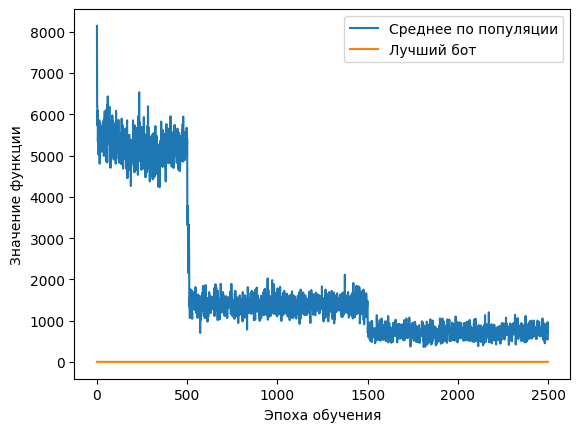

Лучший бот: [4, 2, 1, 0, 2, 3, 0, 2, 2, 4, 1, 3, 5, 1, 3, 0, 4, 5]
Заполненность поездов: [ 8.  8.  8. 10. 10. 10.]
Максимальная вместимость: [10 10 10 12 12 12]


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

train = np.array([10, 10, 10, 12, 12, 12])

size = np.array([1,1,1,1,2,2,2,2,3,3,3,3,4,4,5,5,6,6])

n = 100
nsurv = 20
nnew = n - nsurv
epohs = 2500
mut = 0.4

l = size.shape[0]
trains = train.shape[0]

popul = []
plotmeanval = []
plotminval = []

for i in range(n):
    popul.append([])
    for j in range(l):
        popul[i].append(random.randint(0, trains - 1))

def getSurvPopul(popul, val, nsurv, reverse):
    newpopul = []
    sval = sorted(val, reverse=reverse)
    for i in range(nsurv):
        index = val.index(sval[i])
        newpopul.append(popul[index])
    return newpopul, sval


def getParents(curr_popul, nsurv):
    indexp1 = random.randint(0, nsurv-1)
    indexp2 = random.randint(0, nsurv-1)
    botp1 = curr_popul[indexp1]
    botp2 = curr_popul[indexp2]
    return botp1, botp2


def crossPointFrom2Parents(botp1, botp2, j):
    if random.random() < 0.5:
        return botp1[j]
    else:
        return botp2[j]

for it in range(epohs):

    if it == 500:
        mut = 0.1
    if it == 1500:
        mut = 0.05

    val = []
    for i in range(n):

        bot = popul[i]

        trainfill = np.zeros(trains)

        for j in range(l):
            trainfill[bot[j]] += size[j]

        f = 0

        ratios = []

        for t in range(trains):
            if trainfill[t] > train[t]:
                f += 1000 * (trainfill[t] - train[t])

            ratios.append(trainfill[t] / train[t])

        avg_ratio = np.mean(ratios)
        for r in ratios:
            f += abs(r - avg_ratio)

        val.append(f)

    newpopul, sval = getSurvPopul(popul, val, nsurv, 0)

    plotmeanval.append(sum(val)/len(val))
    plotminval.append(sval[0])

    for i in range(nnew):

        botp1, botp2 = getParents(newpopul, nsurv)

        newbot = []

        for j in range(l):

            x = crossPointFrom2Parents(botp1, botp2, j)

            if random.random() < mut:
                x = random.randint(0, trains-1)

            newbot.append(x)

        newpopul.append(newbot)

    popul = newpopul

plt.plot(plotmeanval,
         label='Среднее по популяции')
plt.plot(plotminval,
         label='Лучший бот')
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение функции')
plt.legend()
plt.show()

bot = popul[0]

print("Лучший бот:", bot)

trainfill = np.zeros(trains)

for j in range(l):
    trainfill[bot[j]] += size[j]

print("Заполненность поездов:", trainfill)
print("Максимальная вместимость:", train)

# Pro
Напишите кластеризацию данных с помощью генетических алгоритмов. Создайте 3 класса двумерных точек, выберите центры классов на достаточном расстоянии и сгенерируйте точки с разбросом так, чтобы классы не пересекались
Нужно расставить индексы точек, к какому классу относится какая точка, с помощью генетического алгоритма. В результате, каждый класс должен состоять из точек одного и того же индекса.
Визуализируйте процесс обучение и итоговый результат

Step 0: -2013.50
Step 1: -2013.50
Step 2: -2013.50
Step 3: -2013.50
Step 4: -2013.50
Step 5: -2674.85
Step 6: -2674.85
Step 7: -2856.10
Step 8: -2876.86
Step 9: -3112.15
Step 10: -3522.82
Step 11: -3707.83
Step 12: -4155.42
Step 13: -4155.42
Step 14: -4846.62
Step 15: -4846.62
Step 16: -5294.83
Step 17: -5294.83
Step 18: -5623.84
Step 19: -5786.88
Step 20: -6767.20
Step 21: -6767.20
Step 22: -6767.20
Step 23: -6767.20
Step 24: -7487.22
Step 25: -7490.93
Step 26: -7490.93
Step 27: -7490.93
Step 28: -7665.89
Step 29: -8403.45
Step 30: -8403.45
Step 31: -9385.64
Step 32: -9385.64
Step 33: -9385.64
Step 34: -9590.53
Step 35: -9590.53
Step 36: -9590.53
Step 37: -9590.53
Step 38: -9590.53
Step 39: -9590.53
Step 40: -9600.58
Step 41: -10063.27
Step 42: -10063.27
Step 43: -10063.27
Step 44: -10441.48
Step 45: -10441.48
Step 46: -10441.48
Step 47: -10441.48
Step 48: -10441.48
Step 49: -10714.44
Step 50: -10949.85
Step 51: -10949.85
Step 52: -10949.85
Step 53: -10949.85
Step 54: -10949.85
Step 5

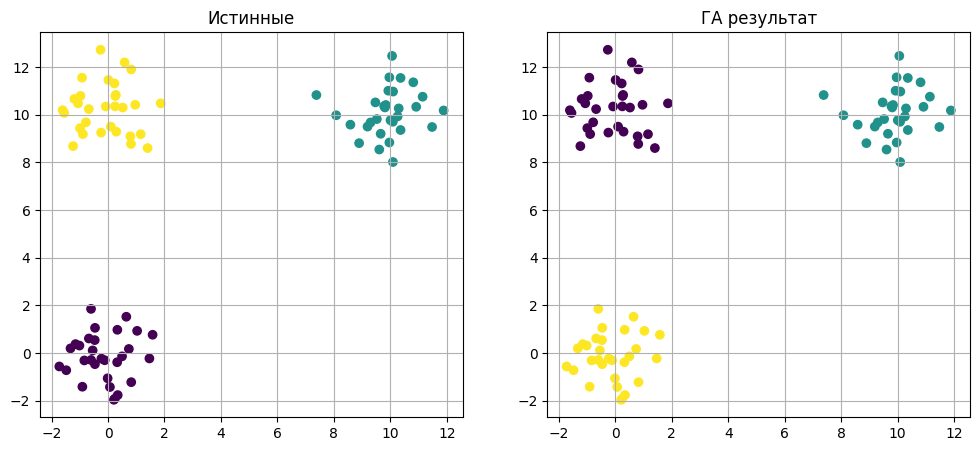

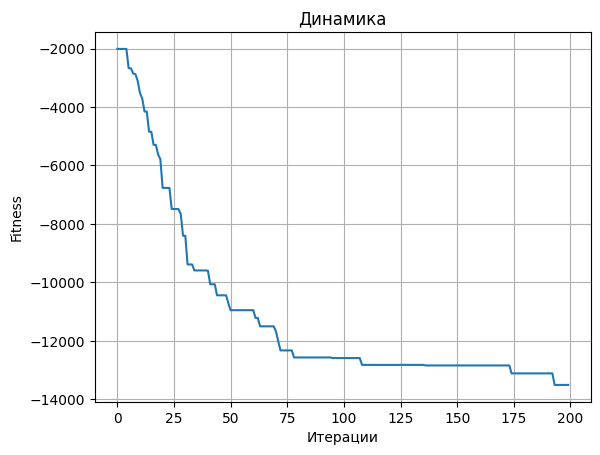

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt

np.random.seed(42)

DOTS_COUNT = 90
CLASSES_COUNT = 3

base_centers = [
    [0, 0],
    [10, 10],
    [0, 10]
]

data = []
labels_true = []

for i, c in enumerate(base_centers):
    block = np.random.randn(DOTS_COUNT // CLASSES_COUNT, 2) + c
    data += list(block)
    labels_true += [i] * (DOTS_COUNT // CLASSES_COUNT)

data = np.array(data)

POP = 200
SURVE = 30
MUT = 0.08
GEN = 200

def init_population():
    return [
        [random.randrange(CLASSES_COUNT) for _ in range(len(data))]
        for _ in range(POP)
    ]

def evaluate(solution):
    same = 0
    diff = 0

    for a in range(len(data)):
        for b in range(a + 1, len(data)):
            d = np.linalg.norm(data[a] - data[b])
            if solution[a] == solution[b]:
                same += d
            else:
                diff += d

    return same - 0.5 * diff

def get_new_population(pop, vals):
    order = sorted(range(len(vals)), key=lambda i: vals[i])
    return [pop[i] for i in order[:SURVE]]

def mix(parent_a, parent_b):
    return [
        parent_a[i] if random.random() > 0.5 else parent_b[i]
        for i in range(len(parent_a))
    ]

def random_change(sol):
    return [
        random.randrange(CLASSES_COUNT) if random.random() < MUT else gene
        for gene in sol
    ]

population = init_population()
progress = []

for step in range(GEN):
    scores = list(map(evaluate, population))
    best_val = min(scores)
    progress.append(best_val)

    print(f"Step {step}: {best_val:.2f}")

    new_popul = get_new_population(population, scores)

    while len(new_popul) < POP:
        a, b = random.sample(new_popul, 2)
        child = mix(a, b)
        child = random_change(child)
        new_popul.append(child)

    population = new_popul

final_scores = list(map(evaluate, population))
best_sol = population[np.argmin(final_scores)]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Истинные")
plt.scatter(data[:, 0], data[:, 1], c=labels_true)
plt.grid()

plt.subplot(1, 2, 2)
plt.title("ГА результат")
plt.scatter(data[:, 0], data[:, 1], c=best_sol)
plt.grid()

plt.show()

plt.plot(progress)
plt.title("Динамика")
plt.xlabel("Итерации")
plt.ylabel("Fitness")
plt.grid()
plt.show()